<a href="https://colab.research.google.com/github/suuu004/Data_analysis/blob/week9/0507_week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 9주차 과제 2310297 **박이수**

In [ ]:
# 한글 폰트 나눔 글꼴 설치
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 데이터 준비
df = pd.read_csv('publicbike_rentalinfo.csv', encoding='cp949')
display(df.head())

plt.rc('font', family='NanumBarunGothic') # 폰트 설정

,자치구,대여소명,기준년월,대여건수,반납건수
0,마포구,108. 서교동 사거리,202507,1277,1314
1,양천구,729. 서부식자재마트 건너편,202507,1658,1808
2,양천구,731. 서울시 도로환경관리센터,202507,3135,3218
3,양천구,733. 신정이펜하우스314동,202507,876,375
4,양천구,734. 신트리공원 입구,202507,2987,2958


**과제 1**

Matplotlib으로 그래프 1개 작성하기

-> 산점도 그래프

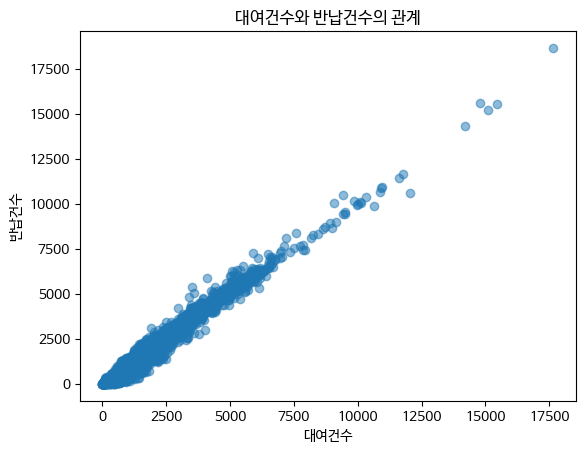

In [ ]:
plt.scatter(df["대여건수"], df["반납건수"], alpha=0.5)
plt.title("대여건수와 반납건수의 관계") # 제목
# 축
plt.xlabel("대여건수")
plt.ylabel("반납건수")
plt.show()

[실행 결과]

위 산점도 그래프를 통해 대여와 반납은 0.99의 상관계수로 거의 일치하게 움직이며, 강서구 등 특정 지역에 이용량이 집중된 쏠림 현상이 뚜렷한 것을 확인할 수 있다.

**과제 2**

Seaborn으로 그래프 2개 작성하기

1. 히스토그램 그래프
2. heatmap 그래프

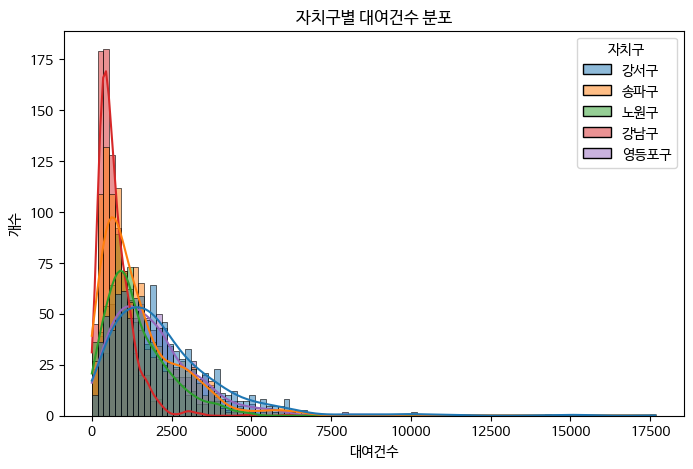

In [ ]:
import seaborn as sns

# 1. 히스토그램 그리기
top5_gu = df["자치구"].value_counts().head(5).index
small_df = df[df["자치구"].isin(top5_gu)]

plt.figure(figsize=(8,5))
sns.histplot(data=small_df, x= "대여건수", hue="자치구", kde= True)

plt.title("자치구별 대여건수 분포") # 제목
# 축
plt.xlabel("대여건수")
plt.ylabel("개수")
plt.show()

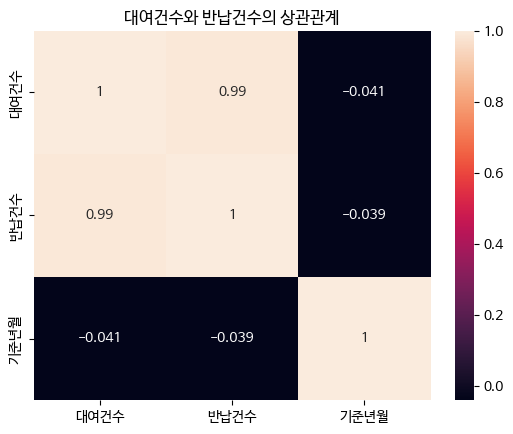

In [ ]:
corr = df[["대여건수", "반납건수", "기준년월"]].corr()
sns.heatmap(data=corr, annot=True)
plt.title("대여건수와 반납건수의 상관관계") # 제목
plt.show()

[실행 결과]

1. 자치구별 대여건수의 분포를 보여주는 히스토그램 그래프를 통해 각 구의 대여건수 양상을 확인할 수 있다. 강남구는 대여건수가 적은 지점이 많고, 강서구/영등포구는 대여량이 높은 케이스가 빈번하다.

2. 히트맵 그래프를 통해 대여와 반납은 거의 세트로 움직이며, 단순히 시간이 흐른다고 해서 대여/반납 건수가 늘어나는 정비례 관계는 나타나지 않는다는 것을 확인할 수 있다.